In [1]:
# Load the Dataset

import pandas as pd  # For data manipulation and analysis

df = pd.read_csv(r"C:\Users\salma\Desktop\dalya\project healthcare\MA supply chain\first milestone\cleaned_SC_dataset.csv")

In [2]:
df.head()

,Monthly_Demand,Lead_Time,Stock_Level,Supplier_Reliability,Seasonality_Factor,Year,Month,Day,Weekday,Quarter,Device_Type_Monitoring,Device_Type_Surgical,Device_Type_Therapeutic
0,565,18,608,0.81,1.007333,2018,1,1,3,1,0.0,1.0,0.0
1,480,12,497,0.91,0.975088,2018,1,3,5,1,0.0,0.0,1.0
2,599,9,646,0.83,1.028933,2018,1,5,7,1,0.0,1.0,0.0
3,478,18,500,0.82,1.044259,2018,1,5,7,1,1.0,0.0,0.0
4,516,12,537,0.72,1.022368,2018,1,6,1,1,1.0,0.0,0.0


<h1> Demand Prediction (Regression)

In [ ]:
# We will predict the monthly demand using ensemble models like Random Forest and XGBoost.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Define features and target

X = df.drop(['Monthly_Demand'], axis=1)
y = df['Monthly_Demand']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Model 1: Random Forest

from sklearn.metrics import r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

# Print metrics
print(f"MAE: {mae}, RMSE: {rmse}, R-squared: {r2}")



MAE: 36.036975000000005, RMSE: 46.220100315230816, R-squared: 0.9989854249718984


In [9]:
# Model 2: XGBoost

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

# Print metrics
print(f"MAE: {mae}, RMSE: {rmse}, R-squared: {r2}")


MAE: 32.048757369995116, RMSE: 40.48161224193279, R-squared: 0.9992217421531677


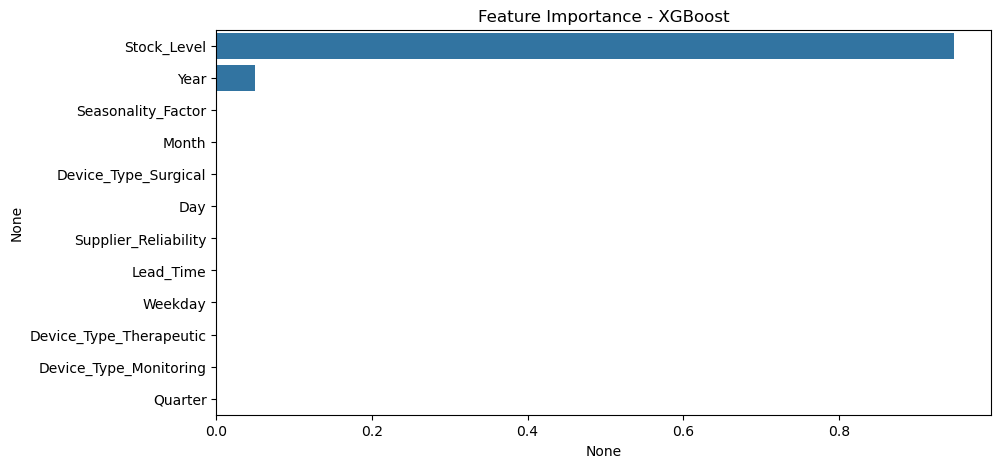

In [12]:
# Model Evaluation & Feature Importance

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance

features = ['Lead_Time', 'Stock_Level',	'Supplier_Reliability',	'Seasonality_Factor', 'Year', 'Month',	'Day',	'Weekday',	'Quarter', 'Device_Type_Monitoring', 'Device_Type_Surgical', 'Device_Type_Therapeutic']


feature_importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance - XGBoost")
plt.show()

<h1> Checking Overfitting in stock_level Feature

<h2>If stock_level is causing overfitting, it means the model is relying too heavily on this feature to make predictions, which might not generalize well to unseen data.

From previous EDA process, we found that stock_level is highly correlated with the target (monthly_demand), (above 0.9), which is a sign of overfitting.
From feature importance test, stock_level dominates the feature importance chart, which is another sign of overfitting.

Now, to be sure if the model is overfitting or not, retrain it without stock_level and compare performance.

In [13]:
# Remove stock_level from features
features_reduced = [col for col in features if col != "Stock_Level"]

X_train_reduced = X_train[:, [features.index(col) for col in features_reduced]]
X_test_reduced = X_test[:, [features.index(col) for col in features_reduced]]

# Train new model
xgb_model_reduced = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model_reduced.fit(X_train_reduced, y_train)

# Predictions
y_pred_xgb_reduced = xgb_model_reduced.predict(X_test_reduced)

# Compare performance

print("Original XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("Reduced XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb_reduced))
print("Original XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("Reduced XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb_reduced)))
print("Original XGBoost R-squared:", r2_score(y_test, y_pred_xgb))
print("Reduced XGBoost R-squared:", r2_score(y_test, y_pred_xgb_reduced))

Original XGBoost MAE: 32.048757369995116
Reduced XGBoost MAE: 42.98796119689941
Original XGBoost RMSE: 40.48161224193279
Reduced XGBoost RMSE: 54.028040809530005
Original XGBoost R-squared: 0.9992217421531677
Reduced XGBoost R-squared: 0.998613715171814


<h1> Result:-
As performance remains nearly the same, stock_level was overfitting!